# **Notebook for Calculating Distances**

## Table of Contents
* [Importing Libraries](#importing_libraries)
* [Data Loading](#loading_data)
* [Calculate Distances](#calculate_distances)
    * [Helper Functions](#helper_function)
    * [Distance to Geometry Points](#distance_to_geometry_points)
    * [Distance to Geometry Polygons](#distance_to_geometry_polygons)
    * [Compute Final Distances](#compute_final_distances)
* [Other Factors](#other_factors)
    * [Air Pollution](#air_pollution)
* [Quality of Life Index](#compute_qol_index)


### Imports <a class="anchor" id="importing_libraries"></a>

In [81]:
import geopandas as gpd
import osmnx as ox
import numpy as np
import networkx as nx
import pandas as pd
from shapely.ops import unary_union
import contextily as cx
import matplotlib.pyplot as plt
from tqdm import tqdm
import h3
import pandana
from shapely import Polygon, LineString

%matplotlib inline
ox.__version__

'1.9.4'

## Data Loading <a class="anchor" id="loading_data"></a>

In [256]:
CRS = "EPSG:25832"

In [257]:
df_green_areas = gpd.read_file('../data/clean_data/green_areas.gpkg')
df_air = gpd.read_file('../data/clean_data/air_quality.gpkg')
df_voting_areas = gpd.read_file('../data/clean_data/voting_areas.gpkg')
df_transport = gpd.read_file('../data/clean_data/transport.gpkg')
df_accommodation = gpd.read_file('../data/clean_data/accommodation.gpkg')
df_schools = gpd.read_file('../data/clean_data/schools.gpkg')
df_hospital = gpd.read_file('../data/clean_data/hospital.gpkg')

assert CRS == df_green_areas.crs == df_air.crs == df_voting_areas.crs == df_transport.crs == df_accommodation.crs == df_schools.crs == df_hospital.crs, "mismatched crs"

Load a street network graph to calculate distances between points

In [258]:
G = ox.graph_from_place(["Copenhagen Municipality", "Frederiksberg Municipality"], network_type="walk", simplify=True)
print(f'Original network type: {type(G)}')

Original network type: <class 'networkx.classes.multidigraph.MultiDiGraph'>


In [259]:
G.number_of_nodes(), G.number_of_edges()

(47085, 130484)

In [260]:
G.graph['crs']

'epsg:4326'

In [261]:
## Convert the crs of G to match the crs of the proejcted data
G = ox.project_graph(G, to_crs=CRS)
print(G.graph['crs'])

EPSG:25832


In [262]:
G_walk = G.to_undirected()

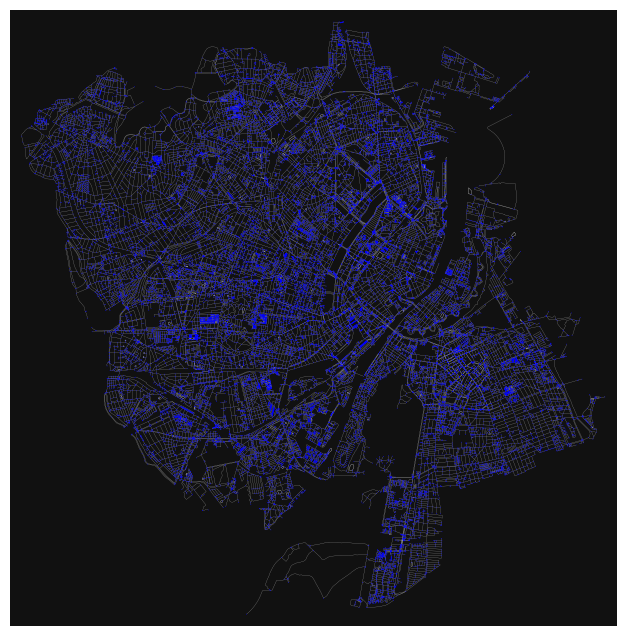

In [263]:
ox.plot_graph(G_walk, node_size=0.3,node_color="b", edge_color="w", edge_linewidth=0.1);

# Calculate distances <a class="anchor" id="calculate_distances"></a>

## Helper functions <a id="helper_function"></a>

In [275]:
## Calculate the nearest node in G_walk for each point on a df
# read documentation for nearest_nodes https://osmnx.readthedocs.io/en/stable/user-reference.html
def nearest_node(gdf, G):
    gdf["nearest_node"], gdf["distance_nearest_node"] = ox.distance.nearest_nodes(G,X=gdf.geometry.x,Y=gdf.geometry.y, return_dist=True)
    return gdf

## Calculate the nearest target point and the distance to it for each point on an original dataframe
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.weighted.multi_source_dijkstra.html#networkx.algorithms.shortest_paths.weighted.multi_source_dijkstra
def dist_to_nodes(original_df, target_df, G, closest_target_name):
    targets = target_df["nearest_node"].unique().tolist()
    targets = [node for node in targets if node in G]

    ## compute paths
    dist, paths = nx.multi_source_dijkstra(G, sources=targets, weight="length")

    ## I do not trust me
    copy_original_df = original_df.copy()

    ## get the closest node
    copy_original_df[closest_target_name] = copy_original_df["nearest_node"].map(lambda x: paths[x][0] if x in paths else np.nan)

    ## get the distance between the nodes
    copy_original_df[f"distance_to_{closest_target_name}"] = copy_original_df["nearest_node"].map(lambda x: dist[x] if x in dist else np.nan)
    
    return copy_original_df
    
## Calculate the shortest path between two nodes and its length just for checking that the distances match and plot
def shortest_distance_network_route(start_node, target_node, G):
    #based on network distance 
    graph_route_length = nx.shortest_path_length(G, start_node, target_node, weight='length')
    
    route = ox.shortest_path(G, start_node, target_node, weight='length')
    
    return route, graph_route_length

## Distances to Geometry Points 

This includes schools, transport stops and hospitals

In [300]:
schools = nearest_node(df_schools, G_walk)
accommodation = nearest_node(df_accommodation, G_walk)
transport = nearest_node(df_transport, G_walk)
hospital = nearest_node(df_hospital, G_walk)

CAREFUL: every target will be mapped to the nearest node, that means that multiple targets can be maped to the 
same node in the graph, and then we get a duplication when we merge. Therefore we will sort the targets by distance to the nearest node, and then we will drop duplicates, keeping the closest target to each node.

In [301]:
schools.sort_values("distance_nearest_node", ascending=True, inplace=True)
print(f"Number of schools: {schools.shape[0]}")
schools.drop_duplicates(subset=["nearest_node"], keep="first", inplace=True)
print(f"Number of schools after dropping duplicates: {schools.shape[0]}")

transport.sort_values("distance_nearest_node", ascending=True, inplace=True)
print(f"Number of transport stops: {transport.shape[0]}")
transport.drop_duplicates(subset=["nearest_node"], keep="first", inplace=True)
print(f"Number of transport stops after dropping duplicates: {transport.shape[0]}")

hospital.sort_values("distance_nearest_node", ascending=True, inplace=True)
print(f"Number of hospitals: {hospital.shape[0]}")
hospital.drop_duplicates(subset=["nearest_node"], keep="first", inplace=True)
print(f"Number of hospitals after dropping duplicates: {hospital.shape[0]}")

Number of schools: 164
Number of schools after dropping duplicates: 164
Number of transport stops: 1184
Number of transport stops after dropping duplicates: 1184
Number of hospitals: 69
Number of hospitals after dropping duplicates: 69


In [302]:
accommodation.head(2)

,osm_id,name,amenity,geometry,nearest_node,distance_nearest_node
0,23540747,NaN,apartments,POINT (722469.200 6177724.345),7766784,47.864968
1,24508264,NaN,apartments,POINT (719548.667 6173443.049),13451737772,50.085985


In [303]:
acc2 = dist_to_nodes(accommodation, schools, G_walk, "nearest_school")
acc3 = dist_to_nodes(acc2, transport, G_walk, "nearest_transport")
acc4 = dist_to_nodes(acc3, hospital, G_walk, "nearest_hospital")
acc4.head(3)

,osm_id,name,amenity,geometry,nearest_node,distance_nearest_node,nearest_school,distance_to_nearest_school,nearest_transport,distance_to_nearest_transport,nearest_hospital,distance_to_nearest_hospital
0,23540747,NaN,apartments,POINT (722469.200 6177724.345),7766784,47.864968,3468162006,359.415,12698949666,207.706,10161917812,648.063
1,24508264,NaN,apartments,POINT (719548.667 6173443.049),13451737772,50.085985,1064307749,813.843,7676422825,346.339,13446380725,1778.819
2,24508268,NaN,apartments,POINT (719514.935 6173413.147),13451737767,49.641436,1064307749,767.958,7676422825,300.454,13446380725,1824.704


In [304]:
assert acc4.shape[0] == accommodation.shape[0] == acc3.shape[0] == acc2.shape[0], "mismatched shape"

total length: 648.063


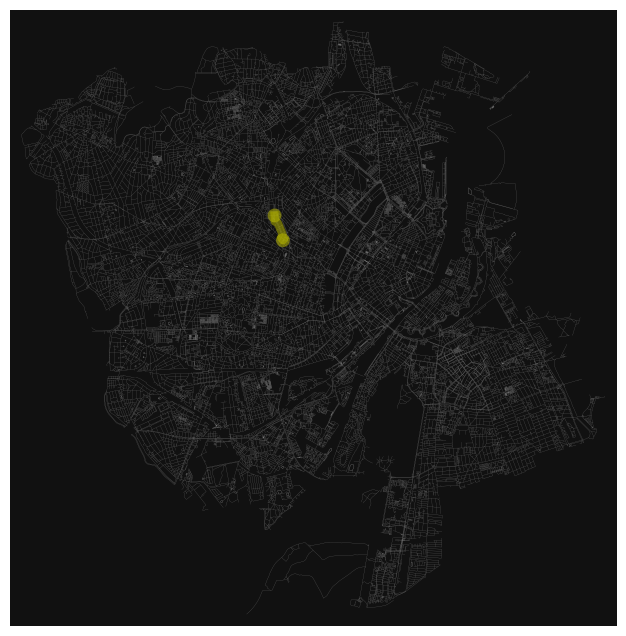

In [305]:
route, total_length = shortest_distance_network_route(start_node=acc4.loc[0, "nearest_node"], target_node=acc4.loc[0, "nearest_hospital"], G=G_walk)
print('total length:', total_length)
fig, ax = ox.plot_graph_route(G_walk, route, route_color="y", route_linewidth=6, node_size=0, edge_linewidth = 0.1)

## Distances to Geometry Polygons 

This includes the green areas

Because this df has nested polygons it will be better to do a unary union and then calculate the distance to the borders of that multipolygon

In [307]:
green_multipolygon = unary_union(df_green_areas.geometry)

In [308]:
## Check if the accommodation points are inside the green areas
inside_green_area = []
for i in tqdm(range(len(df_accommodation))):
    if green_multipolygon.contains(df_accommodation.geometry.iloc[i]):
        #print(f"{i} is inside a green area")
        inside_green_area.append(i)

100%|██████████| 20783/20783 [03:33<00:00, 97.25it/s] 


In [309]:
len(inside_green_area)

22

In [310]:
## get edge points from the multipolygon
# https://shapely.readthedocs.io/en/2.1.2/reference/shapely.MultiLineString.html
green_multipolygon_edges = green_multipolygon.boundary
print(green_multipolygon_edges.geom_type)
points = []
for line in tqdm(green_multipolygon_edges.geoms):
    ## get points from the line
    for d in range(0, int(line.length), 15): # get points every 15 meters
        point = line.line_interpolate_point(d, normalized=False) #https://shapely.readthedocs.io/en/2.1.2/reference/shapely.LineString.html
        points.append(point)
print(len(points))


MultiLineString


100%|██████████| 493/493 [00:00<00:00, 584.97it/s]

29027


In [311]:
green_points = gpd.GeoDataFrame(geometry=points, crs=CRS)

<Axes: >

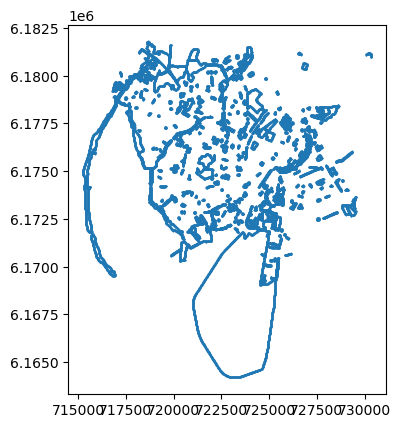

In [312]:
green_points.plot(markersize=0.2)

In [313]:
green_nodes = nearest_node(green_points, G_walk)
green_nodes.tail(2)

,geometry,nearest_node,distance_nearest_node
29025,POINT (726657.956 6181136.831),653926528,7.391873
29026,POINT (726651.215 6181124.360),653926528,15.239848


In [315]:
green_nodes.sort_values("distance_nearest_node", ascending=True, inplace=True)
print(f"Number of green nodes: {green_nodes.shape[0]}")
green_nodes.drop_duplicates(subset=["nearest_node"], keep="first", inplace=True)
print(f"Number of green nodes after dropping duplicates: {green_nodes.shape[0]}")

Number of green nodes: 29027
Number of green nodes after dropping duplicates: 6277


In [316]:
acc5 = dist_to_nodes(acc4, green_nodes, G_walk, "nearest_green_area")
acc5.head()

,osm_id,name,amenity,geometry,nearest_node,distance_nearest_node,nearest_school,distance_to_nearest_school,nearest_transport,distance_to_nearest_transport,nearest_hospital,distance_to_nearest_hospital,nearest_green_area,distance_to_nearest_green_area
0,23540747,NaN,apartments,POINT (722469.200 6177724.345),7766784,47.864968,3468162006,359.415,12698949666,207.706,10161917812,648.063,7766784,0.000
1,24508264,NaN,apartments,POINT (719548.667 6173443.049),13451737772,50.085985,1064307749,813.843,7676422825,346.339,13446380725,1778.819,13451737772,0.000
2,24508268,NaN,apartments,POINT (719514.935 6173413.147),13451737767,49.641436,1064307749,767.958,7676422825,300.454,13446380725,1824.704,13451737767,0.000
3,24508270,NaN,apartments,POINT (719481.570 6173382.595),7676422838,33.289435,1064307749,673.886,7676422825,219.058,13446380725,1918.776,7673263466,18.073
4,24513387,NaN,apartments,POINT (719787.447 6172394.230),281161612,21.757988,13458066567,962.828,12169665442,65.954,13446380725,1482.216,281161612,0.000


In [317]:
acc5.loc[675]

osm_id                                                                6315967
name                                                             A/B Ryparken
amenity                                                            apartments
geometry                          POINT (723535.4695868618 6180638.716565272)
nearest_node                                                       4244807697
distance_nearest_node                                               24.026885
nearest_school                                                     1578282348
distance_to_nearest_school                                            256.925
nearest_transport                                                  4243535480
distance_to_nearest_transport                                          36.514
nearest_hospital                                                   2022890378
distance_to_nearest_hospital                                         1545.185
nearest_green_area                                              

In [318]:
## set to 0 the distance to the nearest green area for the accommodation points that are inside a green area
acc5.loc[inside_green_area, "distance_to_nearest_green_area"] = 0

In [319]:
acc5.loc[675]

osm_id                                                                6315967
name                                                             A/B Ryparken
amenity                                                            apartments
geometry                          POINT (723535.4695868618 6180638.716565272)
nearest_node                                                       4244807697
distance_nearest_node                                               24.026885
nearest_school                                                     1578282348
distance_to_nearest_school                                            256.925
nearest_transport                                                  4243535480
distance_to_nearest_transport                                          36.514
nearest_hospital                                                   2022890378
distance_to_nearest_hospital                                         1545.185
nearest_green_area                                              

In [320]:
test = acc5.sort_values("distance_to_nearest_green_area", ascending=False).reset_index(drop=True)
test.head(10)

,osm_id,name,amenity,geometry,nearest_node,distance_nearest_node,nearest_school,distance_to_nearest_school,nearest_transport,distance_to_nearest_transport,nearest_hospital,distance_to_nearest_hospital,nearest_green_area,distance_to_nearest_green_area
0,633581591,NaN,apartments,POINT (724976.499 6180931.826),9682786922,31.010611,5323316583,541.038,5009884626,389.969,3627941723,746.326,1417486603,1413.684
1,633581593,NaN,apartments,POINT (724922.864 6180935.786),6511187651,21.724143,5323316583,488.062,5009884626,336.993,3627941723,693.350,1417486603,1360.708
2,633581595,NaN,apartments,POINT (724869.102 6180939.697),6511187632,20.155995,5323316583,421.746,5009884626,270.677,3627941723,627.034,1417486603,1294.392
3,571555782,NaN,detached,POINT (726701.985 6171737.170),5481050414,27.817034,1510179861,1056.879,11089114304,529.882,3741609615,1478.917,281683240,1237.928
4,573743934,NaN,detached,POINT (726687.113 6171811.066),5481050414,56.463702,1510179861,1056.879,11089114304,529.882,3741609615,1478.917,281683240,1237.928
5,477247441,NaN,apartments,POINT (726725.410 6171745.385),5481050414,19.592286,1510179861,1056.879,11089114304,529.882,3741609615,1478.917,281683240,1237.928
6,573743911,NaN,detached,POINT (726720.053 6171818.314),5481050414,56.699559,1510179861,1056.879,11089114304,529.882,3741609615,1478.917,281683240,1237.928
7,573743915,NaN,detached,POINT (726701.786 6171815.547),5481050414,55.244354,1510179861,1056.879,11089114304,529.882,3741609615,1478.917,281683240,1237.928
8,472083041,NaN,detached,POINT (724832.848 6180841.398),4646072543,13.953850,5323316583,429.974,5009884626,278.905,3627941723,635.262,1417486603,1223.126
9,573743908,NaN,detached,POINT (726737.604 6171821.314),5481050524,56.369073,1510179861,1021.138,11089114304,494.141,3741609615,1443.176,281683240,1202.187


In [321]:
row = test.loc[0]

start_node = row["nearest_node"]
target_node = row["nearest_green_area"]
dist = row["distance_to_nearest_green_area"]

print("distance:", dist)

distance: 1413.684


total length: 1413.6840000000002


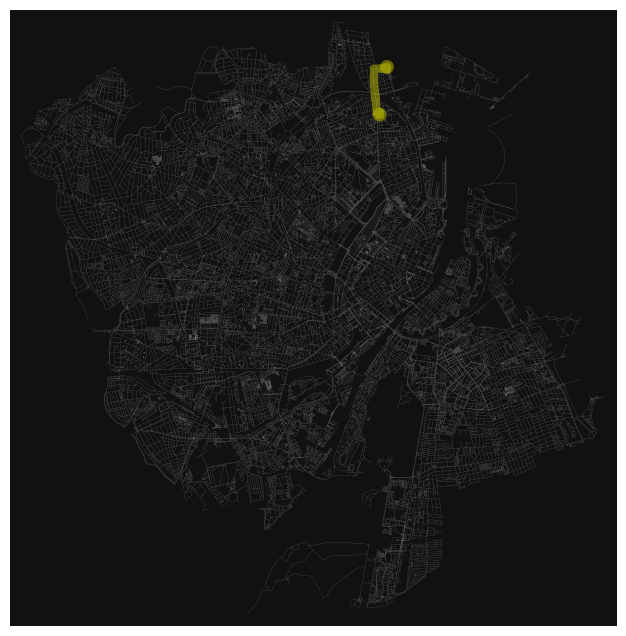

In [322]:
route_test, total_length_test = shortest_distance_network_route(start_node=start_node, target_node=target_node, G=G_walk)
print('total length:', total_length_test)
fig, ax = ox.plot_graph_route(G_walk, route_test, route_color="y", route_linewidth=6, node_size=0, edge_linewidth = 0.1)

In [323]:
assert acc5.shape[0] == accommodation.shape[0] == acc4.shape[0] == acc3.shape[0] == acc2.shape[0], "mismatched shape"

## Compute Final Distances <a id="compute_final_distances"></a>

We will take the computed distance and add the distance to the nearest node calculation. Given a merge between euclidean and network distance

In [324]:
df = acc5.copy()
df.head(2)

,osm_id,name,amenity,geometry,nearest_node,distance_nearest_node,nearest_school,distance_to_nearest_school,nearest_transport,distance_to_nearest_transport,nearest_hospital,distance_to_nearest_hospital,nearest_green_area,distance_to_nearest_green_area
0,23540747,NaN,apartments,POINT (722469.200 6177724.345),7766784,47.864968,3468162006,359.415,12698949666,207.706,10161917812,648.063,7766784,0.0
1,24508264,NaN,apartments,POINT (719548.667 6173443.049),13451737772,50.085985,1064307749,813.843,7676422825,346.339,13446380725,1778.819,13451737772,0.0


In [325]:
df = df.merge(schools[["nearest_node", "distance_nearest_node"]].rename(columns={"nearest_node": "nearest_school", "distance_nearest_node": "school_to_node"}), on='nearest_school', how="left")
df['school_distance'] = df['distance_to_nearest_school'] + df['school_to_node'] + df['distance_nearest_node']
df.drop(columns=["nearest_school", "distance_to_nearest_school", "school_to_node"], inplace=True)

df = df.merge(transport[["nearest_node", "distance_nearest_node"]].rename(columns={"nearest_node": "nearest_transport", "distance_nearest_node": "transport_to_node"}), on='nearest_transport', how="left")
df['transport_distance'] = df['distance_to_nearest_transport'] + df['transport_to_node'] + df['distance_nearest_node']
df.drop(columns=["nearest_transport", "distance_to_nearest_transport", "transport_to_node"], inplace=True)

df = df.merge(hospital[["nearest_node", "distance_nearest_node"]].rename(columns={"nearest_node": "nearest_hospital", "distance_nearest_node": "hospital_to_node"}), on='nearest_hospital', how="left")
df['hospital_distance'] = df['distance_to_nearest_hospital'] + df['hospital_to_node'] + df['distance_nearest_node']
df.drop(columns=["nearest_hospital", "distance_to_nearest_hospital", "hospital_to_node"], inplace=True)

df = df.merge(green_nodes[["nearest_node", "distance_nearest_node"]].rename(columns={"nearest_node": "nearest_green_area", "distance_nearest_node": "green_to_node"}), on='nearest_green_area', how="left")
df['green_distance'] = df['distance_to_nearest_green_area'] + df['green_to_node'] + df['distance_nearest_node']
df.drop(columns=["nearest_green_area", "distance_to_nearest_green_area", "green_to_node"], inplace=True)

##df.drop(columns=["nearest_node", "distance_nearest_node", "name"], inplace=True)

df.head(2)

,osm_id,name,amenity,geometry,nearest_node,distance_nearest_node,school_distance,transport_distance,hospital_distance,green_distance
0,23540747,NaN,apartments,POINT (722469.200 6177724.345),7766784,47.864968,431.964822,268.276004,725.711114,56.812642
1,24508264,NaN,apartments,POINT (719548.667 6173443.049),13451737772,50.085985,889.700009,399.868751,1850.775750,61.283802


In [327]:
assert df.shape[0] == accommodation.shape[0], "mismatched shape"

# Other Factors <a class="anchor" id="other_factors"></a>

## Air Pollution <a id="air_pollution"></a>

In [339]:
df_air.head(2)

,Shape_Leng,ROAD_FID,Mixed_NO2,Mixed_UFP,Mixed_BC,geometry
0,31.898519,2,10.0,18500.0,0.8,"LINESTRING (728133.032 6171374.210, 728141.124..."
1,36.276259,3,9.0,12800.0,0.8,"LINESTRING (725894.255 6167603.511, 725887.421..."


In [340]:
df.head(2)

,osm_id,name,amenity,geometry,nearest_node,distance_nearest_node,school_distance,transport_distance,hospital_distance,green_distance
0,23540747,NaN,apartments,POINT (722469.200 6177724.345),7766784,47.864968,431.964822,268.276004,725.711114,56.812642
1,24508264,NaN,apartments,POINT (719548.667 6173443.049),13451737772,50.085985,889.700009,399.868751,1850.775750,61.283802


In [342]:
df.shape, df_air.shape

((20783, 10), (27985, 6))

In [341]:
## https://geopandas.org/en/v1.1.1/docs/reference/api/geopandas.sjoin_nearest.html#geopandas.sjoin_nearest
merge_air = gpd.sjoin_nearest(df, df_air, how="left")

In [344]:
merge_air.drop(columns=["index_right", "Shape_Leng"], inplace=True)
merge_air.head(2)

,osm_id,name,amenity,geometry,nearest_node,distance_nearest_node,school_distance,transport_distance,hospital_distance,green_distance,ROAD_FID,Mixed_NO2,Mixed_UFP,Mixed_BC
0,23540747,NaN,apartments,POINT (722469.200 6177724.345),7766784,47.864968,431.964822,268.276004,725.711114,56.812642,12867,16.0,5460.0,0.9
1,24508264,NaN,apartments,POINT (719548.667 6173443.049),13451737772,50.085985,889.700009,399.868751,1850.775750,61.283802,5313,12.0,8710.0,0.8


In [345]:
clean_df = merge_air.drop(columns=["nearest_node", "distance_nearest_node", "name"])

In [346]:
merge_air.shape, clean_df.shape, accommodation.shape

((20817, 14), (20817, 11), (20783, 6))

The sizes have changed, but it is lickely that this is due to equidistant streets to a point, then we will like to have both, even it means that we have duplicated rows, because they will have the same distance to the nearest node, but different distances to the air pollution points, and we want to keep both to average later.

# Quality of Life Index <a class="anchor" id="compute_qol_index"></a>

In [347]:
qol_df = clean_df.copy()
qol_df.head(2)

,osm_id,amenity,geometry,school_distance,transport_distance,hospital_distance,green_distance,ROAD_FID,Mixed_NO2,Mixed_UFP,Mixed_BC
0,23540747,apartments,POINT (722469.200 6177724.345),431.964822,268.276004,725.711114,56.812642,12867,16.0,5460.0,0.9
1,24508264,apartments,POINT (719548.667 6173443.049),889.700009,399.868751,1850.775750,61.283802,5313,12.0,8710.0,0.8


In [348]:
weights = {
    "school_distance": 0.25,
    "transport_distance": 0.25,
    "hospital_distance": 0.25,
    "green_distance": 0.12, 
    "Mixed_NO2": 0.13
}

qol_df["qol_index"] = qol_df["school_distance"] * weights["school_distance"] + qol_df["transport_distance"] * weights["transport_distance"] + qol_df["hospital_distance"] * weights["hospital_distance"] + qol_df["green_distance"] * weights["green_distance"] + qol_df["Mixed_NO2"] * weights["Mixed_NO2"]

In [349]:
qol_df

,osm_id,amenity,geometry,school_distance,transport_distance,hospital_distance,green_distance,ROAD_FID,Mixed_NO2,Mixed_UFP,Mixed_BC,qol_index
0,23540747,apartments,POINT (722469.200 6177724.345),431.964822,268.276004,725.711114,56.812642,12867,16.0,5460.0,0.9,365.385502
1,24508264,apartments,POINT (719548.667 6173443.049),889.700009,399.868751,1850.775750,61.283802,5313,12.0,8710.0,0.8,794.000184
2,24508268,apartments,POINT (719514.935 6173413.147),843.370460,353.539201,1896.216200,62.014092,31625,19.0,13000.0,1.1,783.193156
3,24508270,apartments,POINT (719481.570 6173382.595),732.946459,255.791200,1973.936199,75.207280,31843,20.0,12600.0,1.1,752.293338
4,24513387,apartments,POINT (719787.447 6172394.230),1058.237922,97.487996,1525.844752,29.245263,31381,14.0,15100.0,1.0,675.722099
...,...,...,...,...,...,...,...,...,...,...,...,...
20778,1446990905,detached,POINT (728252.370 6173627.154),673.626062,221.900258,894.679661,396.474984,18592,10.0,12200.0,0.8,496.428493
20779,1446990907,detached,POINT (728251.542 6173645.397),658.755251,207.029447,879.808850,381.604173,18592,10.0,12200.0,0.8,483.490888
20780,1472970330,detached,POINT (728788.277 6173789.477),550.564928,287.847617,1811.110069,258.292429,20894,15.0,20700.0,1.0,695.325745
20781,1473556190,detached,POINT (727893.321 6174473.745),359.107121,170.807060,1235.541162,121.864227,12906,11.0,7920.0,0.7,457.417543


In [350]:
qol_df.to_file('../data/clean_data/qol_index.gpkg')